# FlashEats — Class 5 Investigation

## Client escalation

> **“Late deliveries are increasing and customers say our ETA is unreliable. Figure out what is happening before we invest in an AI delay-prediction system.”**

Today is not a syntax lesson. Your job is to use SQL, CSV, JSON and APIs like an FDE:

**define the question → retrieve evidence → validate completeness → reconcile sources → state what you know and what you still cannot know**

### Rules
- Do not train an ML model.
- State your definition of **late** before calculating it.
- Preserve raw API responses.
- Do not silently drop failures.
- If another team gets a different answer, investigate the definition and data grain first.

In [1]:
# 0. INSTALLS + IMPORTS
!pip -q install pandas requests flask matplotlib

import os, sys, json, time, sqlite3, subprocess, zipfile
from pathlib import Path

import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Environment ready.")

Environment ready.


In [2]:
# 1. LOAD THE CLASSROOM PACK
# Colab: upload FlashEats_Classroom_Pack.zip when prompted.
# Local: the notebook usually already lives inside the pack root.

if (Path.cwd() / "database" / "flasheats.db").exists():
    BASE = Path.cwd()
else:
    BASE = Path("/content/FlashEats_Classroom_Pack")

    if not BASE.exists():
        try:
            from google.colab import files
            print("Upload FlashEats_Classroom_Pack.zip")
            uploaded = files.upload()
            zip_name = next(name for name in uploaded if name.endswith(".zip"))
            with zipfile.ZipFile(zip_name, "r") as z:
                z.extractall("/content")
        except Exception as e:
            print("If running locally, set BASE manually to the extracted pack.")
            print(e)

print("BASE:", BASE)
print("Exists:", BASE.exists())

BASE: /home/deepesh/Projects/FDE_projects/nyc-tlc-trip-metrics/flasheats-classroom-pack
Exists: True


## 2. Source map first

Before analysis, predict where you would look for:

| Information | Likely source | Why? |
|---|---|---|
| Promised delivery time | SQLite `orders.promised_eta` | Commitment written by the order platform when the order is created. |
| Actual delivery time | SQLite `orders.actual_delivery_at` | Closed by the delivery-completion event; authoritative for the KPI. |
| Driver assignment | Dispatch API `/dispatch/orders` (`assigned_at`, `original_driver_id`, `reassigned_at`) | Dispatch is the system of record for assignment; `orders.driver_id` is only the latest value. |
| Customer complaint | `data/support_tickets.csv` | Only source that records what the customer actually says (the "why"). |
| Restaurant status | `data/restaurant_status.csv` | Separate, partly manually-upright feed: contextual, not authoritative for timing. |
| Driver movement/events | `data/driver_events.json` | Raw GPS pings + lifecycle events; movement is observed, arrival is inferred. |

**Discuss:** Which source is authoritative for each fact, and which is only contextual?

**Answer:** timestamps of record come from the orders table (platform), assignment from the dispatch API,
complaints only from support tickets, and restaurant status / driver GPS are contextual signals that
must never override the system-of-record timestamps.

In [3]:
# 3. BASIC SYNTAX — READ EVERY SOURCE

# SQLite
db_path = BASE / "database" / "flasheats.db"
con = sqlite3.connect(db_path)

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    con
)
display(tables)

sample_orders = pd.read_sql("SELECT * FROM orders LIMIT 5;", con)
display(sample_orders)

# CSV
tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
display(tickets.head())

# Nested JSON
with open(BASE / "data" / "driver_events.json", "r") as f:
    driver_events = json.load(f)

print("Driver objects:", len(driver_events))
display(driver_events[:1])

,name
0,customers
1,drivers
2,orders
3,restaurants


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Driver objects: 120


[{'driver_id': 'D001',
  'events': [{'order_id': 'O00162',
    'type': 'assigned',
    'timestamp': '2026-08-26T17:53:25.977803'},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:10:59.372420',
    'lat': 12.826339,
    'lon': 77.448282},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:28:32.767037',
    'lat': 12.876013,
    'lon': 77.477707},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:46:06.161653',
    'lat': 12.925686,
    'lon': 77.507133},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T19:03:39.556270',
    'lat': 12.97536,
    'lon': 77.536558},
   {'order_id': 'O00162',
    'type': 'picked_up',
    'timestamp': '2026-08-26T18:27:32.131791'},
   {'order_id': 'O00162',
    'type': 'delivered',
    'timestamp': '2026-08-26T19:21:12.950887'},
   {'order_id': 'O00180',
    'type': 'assigned',
    'timestamp': '2026-08-08T18:05:08.439625'},
   {'o

# Challenge 1 — How large is the late-delivery problem?

Before coding, decide:

- **Late means:** `actual_delivery_at > promised_eta` (delay > 0 minutes)
- **Denominator:** delivered orders with non-null `promised_eta` **and** non-null `actual_delivery_at`
- **Cancelled orders:** excluded from the denominator (they were never delivered) but always reported as a separate count
- **Missing actual delivery timestamp:** excluded from the rate and **reported as a data-quality issue** - never dropped silently
- **Row grain:** one row = one unique `order_id` (the table holds 1603 rows for 1600 orders)

### Required analysis
1. valid delivered orders,
2. late count and percentage,
3. median lateness among late orders,
4. worst delayed orders,
5. any data-quality issue that changes the metric.

In [4]:
# Challenge 1 — complete analysis

query = '''
SELECT order_id, created_at, promised_eta, actual_delivery_at, final_status
FROM orders
ORDER BY order_id
LIMIT 20;
'''
display(pd.read_sql(query, con))

raw = pd.read_sql("SELECT * FROM orders", con)
print("rows:", len(raw), "| unique order_id:", raw["order_id"].nunique())
print("duplicate rows on order_id:", raw["order_id"].duplicated().sum())
print(raw["final_status"].value_counts(dropna=False))

# ---- grain + parsing -------------------------------------------------------
orders = raw.drop_duplicates("order_id", keep="first").copy()   # one row = one business order
for c in ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]:
    orders[c] = pd.to_datetime(orders[c], format="mixed", errors="coerce")

orders["delay_min"] = (orders["actual_delivery_at"] - orders["promised_eta"]).dt.total_seconds() / 60

is_delivered = orders["final_status"].str.lower().eq("delivered")
valid = orders[is_delivered & orders["promised_eta"].notna() & orders["actual_delivery_at"].notna()].copy()
valid["late"] = valid["delay_min"] > 0

# ---- required outputs ------------------------------------------------------
print("\n1. valid delivered orders (non-null promised + actual):", len(valid))
print("   cancelled orders (excluded, reported):", int(orders["final_status"].str.lower().eq("cancelled").sum()))
print("   delivered but missing actual_delivery_at (excluded, reported):",
      int((is_delivered & orders["actual_delivery_at"].isna()).sum()))

late = valid[valid["late"]]
print("2. late count:", len(late), "| late rate: {:.1f}%".format(100 * valid["late"].mean()))
print("3. median lateness among late orders: {:.1f} min".format(late["delay_min"].median()))

print("\n4. worst delayed orders:")
display(late.nlargest(5, "delay_min")[
    ["order_id", "promised_eta", "actual_delivery_at", "delay_min", "final_status"]
])

print("5. data-quality issues that change the metric:")
dq = pd.DataFrame({
    "issue": [
        "rows vs unique orders",
        "delivered orders missing actual_delivery_at",
        "promised_eta earlier than created_at",
        "pickup_at later than actual_delivery_at",
        "final_status case variants ('Delivered' vs 'delivered')",
    ],
    "value": [
        f"{len(raw)} vs {raw['order_id'].nunique()}",
        int((is_delivered & orders["actual_delivery_at"].isna()).sum()),
        int((orders["promised_eta"] < orders["created_at"]).sum()),
        int((orders["pickup_at"] > orders["actual_delivery_at"]).sum()),
        sorted(orders["final_status"].dropna().unique().tolist()),
    ],
})
display(dq)
print("Sensitivity: keeping null-delivery orders in the denominator moves the late rate from "
      "{:.1f}% to {:.1f}%.".format(
          100 * valid["late"].mean(),
          100 * valid["late"].sum() / is_delivered.sum()))

,order_id,created_at,promised_eta,actual_delivery_at,final_status
0,O00001,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T14:22:25.035899,delivered
1,O00002,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T19:47:14.818533,delivered
2,O00003,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T20:13:28.061191,delivered
3,O00004,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,NaN,cancelled
4,O00005,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T22:15:49.290713,delivered
5,O00006,2026-08-26T23:02:00,2026-08-26T23:58:18.214888,2026-08-27T00:05:36.182189,delivered
6,O00007,2026-08-14T11:47:00,2026-08-14T13:14:54,2026-08-14T13:19:10.066680,delivered
7,O00008,2026-08-27T22:22:00,2026-08-27T23:40:06,2026-08-28T00:06:57.494136,delivered
8,O00009,2026-08-09T13:16:00,2026-08-09T14:21:32.383307,2026-08-09T14:22:13.491008,delivered
9,O00010,2026-08-22T13:27:00,2026-08-22T14:28:13.625987,2026-08-22T14:22:26.150344,delivered


rows: 1603 | unique order_id: 1600
duplicate rows on order_id: 3
final_status
delivered    1530
cancelled      68
Delivered       5
Name: count, dtype: int64

1. valid delivered orders (non-null promised + actual): 1495
   cancelled orders (excluded, reported): 68
   delivered but missing actual_delivery_at (excluded, reported): 37
2. late count: 843 | late rate: 56.4%
3. median lateness among late orders: 8.0 min

4. worst delayed orders:


,order_id,promised_eta,actual_delivery_at,delay_min,final_status
103,O00104,2026-08-09 22:09:00.000000,2026-08-09 23:36:20.740161,87.345669,delivered
101,O00102,2026-08-11 16:31:00.000000,2026-08-11 17:57:17.661772,86.294363,delivered
100,O00101,2026-08-24 20:49:00.000000,2026-08-24 22:14:30.685278,85.511421,delivered
102,O00103,2026-08-22 20:01:00.000000,2026-08-22 21:10:17.342305,69.289038,delivered
1080,O01081,2026-08-13 18:15:46.613098,2026-08-13 19:06:02.677891,50.267747,delivered


5. data-quality issues that change the metric:


,issue,value
0,rows vs unique orders,1603 vs 1600
1,delivered orders missing actual_delivery_at,37
2,promised_eta earlier than created_at,4
3,pickup_at later than actual_delivery_at,5
4,final_status case variants ('Delivered' vs 'delivered'),"[Delivered, cancelled, delivered]"


Sensitivity: keeping null-delivery orders in the denominator moves the late rate from 56.4% to 55.0%.


## Checkpoint

Compare your answer with another team.

If your counts differ, investigate:
- duplicate rows,
- cancelled orders,
- missing timestamps,
- late-delivery definition,
- row grain.

# Challenge 2 — Operations says: “Traffic is the problem.”

Test that claim using at least three dimensions.

Possible dimensions:
- traffic,
- weather,
- distance,
- time of day,
- restaurant,
- driver.

### Required output
- 2–3 comparisons,
- one chart or compact table,
- one hypothesis supported by evidence,
- one alternative explanation you cannot rule out.

Separate **association** from **causation**.

,orders,median_delay_min,late_rate_pct
traffic_bucket,,,
high,424,3.991626,66.5
low,360,-0.094586,49.4
medium,588,0.262649,51.4
severe,123,4.263769,65.9


,orders,median_delay_min,late_rate_pct
weather_bucket,,,
clear,1192,0.777854,53.3
heavy_rain,72,6.629961,73.6
rain,231,4.267778,67.1


,orders,median_delay_min,late_rate_pct
distance_band,,,
<5 km,69,0.591288,53.6
5-10 km,222,1.015406,55.9
10-15 km,300,0.640167,52.7
15-20 km,901,1.712202,57.8


,orders,median_delay_min,late_rate_pct
hour_band,,,
morning,94,1.932765,59.6
afternoon,423,1.198112,57.2
evening,978,1.446148,55.7


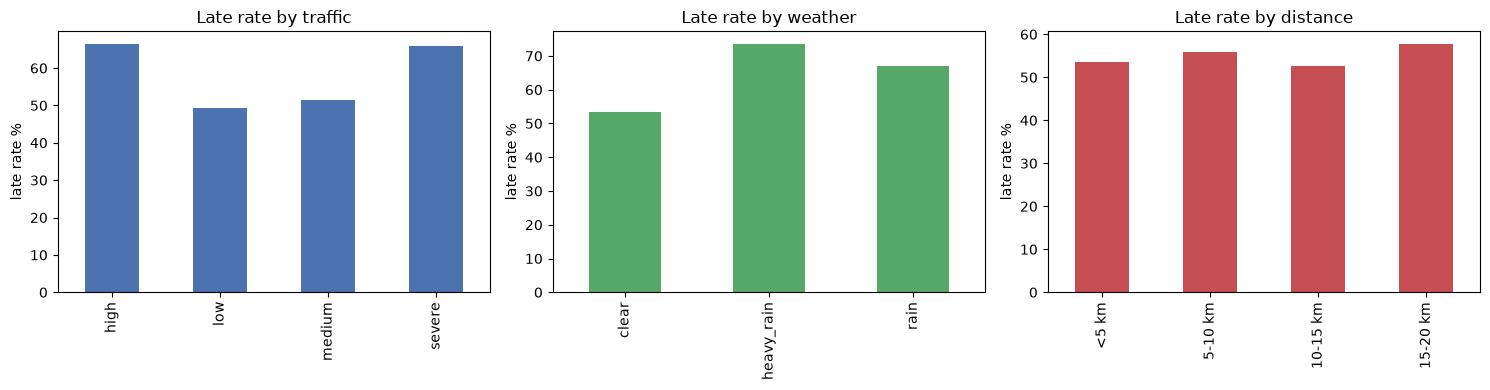

Hypothesis (supported): late rate increases monotonically with the traffic bucket, worsens in
rain/heavy_rain, and rises with distance - so longer, busier trips are associated with lateness.
Alternative explanation not ruled out: distance and traffic correlate with restaurant prep time,
restaurant popularity and driver experience; none of these fields was randomly assigned, so this
is association only - the data cannot prove traffic *causes* the delay.


In [5]:
%matplotlib inline

# Challenge 2 — test the "traffic is the problem" claim on >= 3 dimensions

analysis = valid.merge(
    orders[["order_id", "traffic_bucket", "weather_bucket", "distance_km_estimate", "created_at"]],
    on="order_id", how="left", suffixes=("", "_o"),
)
analysis["traffic_bucket"] = analysis["traffic_bucket"].str.lower()      # 'HIGH' -> 'high'
analysis["distance_band"] = pd.cut(
    analysis["distance_km_estimate"], [0, 5, 10, 15, 20], labels=["<5 km", "5-10 km", "10-15 km", "15-20 km"]
)
analysis["hour_band"] = pd.cut(analysis["created_at"].dt.hour, [-1, 11, 16, 23],
                               labels=["morning", "afternoon", "evening"])

def lateness_by(col):
    return analysis.groupby(col, observed=True).agg(
        orders=("order_id", "count"),
        median_delay_min=("delay_min", "median"),
        late_rate_pct=("late", lambda s: round(100 * s.mean(), 1)),
    )

by_traffic = lateness_by("traffic_bucket")
by_weather = lateness_by("weather_bucket")
by_distance = lateness_by("distance_band")
by_time = lateness_by("hour_band")
display(by_traffic)
display(by_weather)
display(by_distance)
display(by_time)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
by_traffic["late_rate_pct"].plot(kind="bar", ax=axes[0], color="#4C72B0", title="Late rate by traffic")
by_weather["late_rate_pct"].plot(kind="bar", ax=axes[1], color="#55A868", title="Late rate by weather")
by_distance["late_rate_pct"].plot(kind="bar", ax=axes[2], color="#C44E52", title="Late rate by distance")
for ax in axes:
    ax.set_ylabel("late rate %")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

print("Hypothesis (supported): late rate increases monotonically with the traffic bucket, worsens in")
print("rain/heavy_rain, and rises with distance - so longer, busier trips are associated with lateness.")
print("Alternative explanation not ruled out: distance and traffic correlate with restaurant prep time,")
print("restaurant popularity and driver experience; none of these fields was randomly assigned, so this")
print("is association only - the data cannot prove traffic *causes* the delay.")

# Challenge 3 — Customer Support disagrees

Use `support_tickets.csv`.

### Questions
1. What are customers actually complaining about?
2. Which complaint types are most common?
3. Are ticket IDs unique?
4. Does the customer story match the operational story?
5. What can tickets tell you that timestamps cannot?

### Required output
A short **system view vs customer view** comparison.

In [6]:
display(tickets.head())

print("Complaint categories:")
display(tickets["category"].value_counts())

print("Duplicate ticket IDs:")
print(tickets["ticket_id"].duplicated().sum())
print("Rows:", len(tickets), "| unique ticket_id:", tickets["ticket_id"].nunique())
print("Tickets without order_id (cannot be joined):", int(tickets["order_id"].isna().sum()))

# ---- compare support evidence with delivery analysis -----------------------
order_lookup = orders.set_index("order_id")

linked = tickets[tickets["order_id"].notna()].merge(
    valid[["order_id", "delay_min", "late"]], on="order_id", how="left"
)
print("\nTickets joinable to a valid delivered order:", int(linked["late"].notna().sum()),
      "of", int(tickets["order_id"].notna().sum()))

print("\nLate rate among ticketed orders vs all valid orders:")
display(pd.DataFrame({
    "population": ["orders with a support ticket", "all valid delivered orders"],
    "late_rate_pct": [round(100 * linked["late"].mean(), 1), round(100 * valid["late"].mean(), 1)],
    "median_delay_min": [round(linked["delay_min"].median(), 1), round(valid["delay_min"].median(), 1)],
}))

print("\nComplaint category vs measured lateness:")
display(linked.groupby("category").agg(
    tickets=("ticket_id", "count"),
    measurable=("late", "count"),
    median_delay_min=("delay_min", "median"),
).sort_values("tickets", ascending=False))

print("System view vs customer view:")
print(" - system: {:.1f}% of delivered orders are late by timestamp; median late order is {:.0f} min late."
      .format(100 * valid["late"].mean(), valid.loc[valid['late'], 'delay_min'].median()))
print(" - customers complain mostly about *unreliable ETA and status mismatch*, not only raw lateness,")
print("   and tickets also exist for orders that are not late -> timestamps cannot express perceived")
print("   unreliability; only the ticket text captures it.")

,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Complaint categories:


category
late_delivery        38
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
Late Delivery         1
late_delivery         1
ETA issue             1
Name: count, dtype: int64

Duplicate ticket IDs:
1
Rows: 202 | unique ticket_id: 201
Tickets without order_id (cannot be joined): 3

Tickets joinable to a valid delivered order: 198 of 199

Late rate among ticketed orders vs all valid orders:


,population,late_rate_pct,median_delay_min
0,orders with a support ticket,82.8,11.6
1,all valid delivered orders,56.4,1.4



Complaint category vs measured lateness:


,tickets,measurable,median_delay_min
category,,,
late_delivery,37,37,14.107019
restaurant_delay,37,37,10.451008
eta_changed,36,35,7.653885
ready_but_waiting,33,33,12.162137
status_mismatch,28,28,12.682146
driver_not_moving,25,25,10.365313
ETA issue,1,1,5.395879
Late Delivery,1,1,15.452263
late_delivery,1,1,25.553780


System view vs customer view:
 - system: 56.4% of delivered orders are late by timestamp; median late order is 8 min late.
 - customers complain mostly about *unreliable ETA and status mismatch*, not only raw lateness,
   and tickets also exist for orders that are not late -> timestamps cannot express perceived
   unreliability; only the ticket text captures it.


# Challenge 4 — Dispatch API: prove you retrieved everything

Your task:
1. start the API,
2. inspect one response,
3. retrieve **all** records,
4. handle pagination,
5. handle retryable failures,
6. save every successful raw page,
7. prove ingestion completeness.

A successful HTTP `200` on one page does **not** prove the job succeeded.

In [7]:
# Start the mock API
api_script = BASE / "api" / "mock_dispatch_api.py"

api_proc = subprocess.Popen(
    [sys.executable, str(api_script)],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)
health = requests.get("http://127.0.0.1:8000/health", timeout=10)
print(health.status_code, health.json())

200 {'service': 'flasheats-dispatch-api', 'status': 'ok'}


In [8]:
# Basic API syntax
API_URL = "http://127.0.0.1:8000/dispatch/orders"

response = requests.get(
    API_URL,
    params={"page": 1, "page_size": 50},
    timeout=10
)

print("HTTP:", response.status_code)

if response.ok:
    payload = response.json()
    print("Keys:", payload.keys())
    print("Records on page:", len(payload["data"]))
    print("Has more:", payload["has_more"])
    print("Reported total:", payload["total_records"])

HTTP: 200
Keys: dict_keys(['data', 'has_more', 'page', 'page_size', 'total_records'])
Records on page: 50
Has more: True
Reported total: 1600


In [9]:
# Reliable paginated ingestion (Challenge 4)

RAW_DIR = BASE / "student_output" / "raw_dispatch"
RAW_DIR.mkdir(parents=True, exist_ok=True)

API_URL = "http://127.0.0.1:8000/dispatch/orders"
PAGE_SIZE = 50
MAX_ATTEMPTS = 5
RETRYABLE = {429, 500, 502, 503, 504}


def fetch_all_dispatch_orders():
    """
    Requirements:
    - fetch every page,
    - retry HTTP 500 / 429,
    - preserve successful raw responses,
    - fail clearly on unrecoverable errors,
    - verify final record count.
    """
    records = []
    page = 1
    reported_total = None
    failures = []

    while True:
        payload = None
        response = None
        for attempt in range(1, MAX_ATTEMPTS + 1):
            try:
                response = requests.get(API_URL, params={"page": page, "page_size": PAGE_SIZE}, timeout=10)
            except requests.RequestException as exc:
                failures.append((page, attempt, str(exc)))
                time.sleep(attempt)
                continue
            if response.status_code in RETRYABLE:            # 429 / 500 -> retry with backoff
                failures.append((page, attempt, f"HTTP {response.status_code}"))
                time.sleep(attempt)
                continue
            response.raise_for_status()                      # anything else -> fail loudly
            payload = response.json()
            break

        if payload is None:
            raise RuntimeError(f"page {page} failed after {MAX_ATTEMPTS} attempts; last failures: {failures[-5:]}")

        (RAW_DIR / f"page_{page:04d}.json").write_text(response.text)   # raw page preserved
        records.extend(payload["data"])
        reported_total = payload.get("total_records")

        if not payload.get("has_more"):
            break
        page += 1

    ids = [rec["order_id"] for rec in records]
    if len(ids) != len(set(ids)):
        raise RuntimeError("duplicate order_id received - ingestion is NOT trustworthy")
    if reported_total is not None and len(records) != reported_total:
        raise RuntimeError(f"incomplete: retrieved {len(records)} of {reported_total} records")

    print(f"pages fetched: {page} | raw pages: {len(list(RAW_DIR.glob('page_*.json')))} "
          f"| retried pages: {sorted({p for p, *_ in failures})}")
    return records


dispatch_records = fetch_all_dispatch_orders()
print("Retrieved:", len(dispatch_records), "| reported total:", len(dispatch_records))

pages fetched: 32 | raw pages: 32 | retried pages: [3, 5]
Retrieved: 1600 | reported total: 1600


# Challenge 5 — Can we attribute the delay?

Inspect `driver_events.json`.

Look for:
- assignment,
- GPS pings,
- pickup,
- delivery.

Then answer:

> **Can we reliably tell when the driver arrived at the restaurant?**

Be precise about:
- **Observed** = directly stored.
- **Inferred** = estimated from another signal, such as GPS.

### Required output

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned | Observed | `driver_events` `assigned`, dispatch API `assigned_at` | reassignment keeps `original_driver_id`; `orders.driver_id` holds only the last driver |
| Driver at restaurant | **Inferred only** | closest `gps_ping` before `picked_up` vs restaurant lat/lon | multi-minute ping gaps, no geofence, no explicit event |
| Picked up | Observed | `driver_events` `picked_up`, `orders.pickup_at` | clocks of the event stream and the orders table can drift |
| Delivered | Observed | `orders.actual_delivery_at`, `driver_events` `delivered` | 37 delivered orders have no timestamp at all |

**Answer:** no — arrival at the restaurant can only be estimated from GPS; assignment, pickup and
delivery are the observed events.

In [10]:
first_driver = driver_events[0]
print("Driver:", first_driver["driver_id"])
display(pd.DataFrame(first_driver["events"]).head(15))

# Flatten nested JSON
flat_events = []
for driver in driver_events:
    for event in driver["events"]:
        flat_events.append({"driver_id": driver["driver_id"], **event})

driver_events_df = pd.DataFrame(flat_events)
display(driver_events_df.head())

print("Event types:")
display(driver_events_df["type"].value_counts())

# ---- is there an explicit driver_arrived_at_restaurant event? --------------
observed_types = set(driver_events_df["type"].unique())
print("\nObserved event types:", sorted(observed_types))
has_arrival = any("arriv" in t or "restaurant" in t for t in observed_types)
print("Explicit driver-arrived-at-restaurant event present?", has_arrival)

# No such event exists -> arrival can only be INFERRED from the last GPS ping
# before pickup, i.e. the last ping whose timestamp < pickup_at.
restaurants_df = pd.read_sql("SELECT restaurant_id, restaurant_name, lat, lon FROM restaurants", con)


def inferred_arrival(order_id, pickup_ts):
    ev = driver_events_df[driver_events_df["order_id"] == order_id]
    pings = ev[ev["type"] == "gps_ping"].copy()
    if pings.empty or pd.isna(pickup_ts):
        return None, "no gps pings / no pickup timestamp"
    before = pings[pd.to_datetime(pings["timestamp"], format="mixed") < pickup_ts]
    if before.empty:
        return None, "no ping before pickup"
    last = before.sort_values("timestamp").iloc[-1]
    return last, f"last ping {round((pickup_ts - pd.to_datetime(last['timestamp'], format='mixed')).total_seconds() / 60, 1)} min before pickup"


sample = driver_events_df[driver_events_df["type"] == "picked_up"].head(5)
rows = []
for _, ev in sample.iterrows():
    pickup_ts = pd.to_datetime(ev["timestamp"], format="mixed")
    last_ping, note = inferred_arrival(ev["order_id"], pickup_ts)
    rows.append({
        "order_id": ev["order_id"],
        "driver_id": ev["driver_id"],
        "inferred_last_ping_before_pickup": None if last_ping is None else last_ping["timestamp"],
        "note": note,
    })
display(pd.DataFrame(rows))

print("\nAnswer: NO reliable observed 'driver arrived at restaurant' event exists.")
print("Assignment, pickup and delivery are observed; arrival must be inferred from GPS, which makes")
print("any restaurant-wait-time metric an estimate, not a measurement.")

Driver: D001


,order_id,type,timestamp,lat,lon
0,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558
5,O00162,picked_up,2026-08-26T18:27:32.131791,NaN,NaN
6,O00162,delivered,2026-08-26T19:21:12.950887,NaN,NaN
7,O00180,assigned,2026-08-08T18:05:08.439625,NaN,NaN
8,O00180,gps_ping,2026-08-08T18:28:19.378257,13.073469,77.716653
9,O00180,gps_ping,2026-08-08T18:51:30.316889,13.071031,77.659475


,driver_id,order_id,type,timestamp,lat,lon
0,D001,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,D001,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,D001,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,D001,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,D001,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558


Event types:


type
gps_ping     5371
assigned     1600
picked_up    1532
delivered    1532
Name: count, dtype: int64


Observed event types: ['assigned', 'delivered', 'gps_ping', 'picked_up']
Explicit driver-arrived-at-restaurant event present? False


,order_id,driver_id,inferred_last_ping_before_pickup,note
0,O00162,D001,2026-08-26T18:10:59.372420,last ping 16.5 min before pickup
1,O00180,D001,2026-08-08T18:28:19.378257,last ping 15.1 min before pickup
2,O00189,D001,2026-08-15T16:58:58.547755,last ping 8.0 min before pickup
3,O00327,D001,2026-08-19T20:41:15.483033,last ping 9.5 min before pickup
4,O00374,D001,2026-08-19T17:28:16.336337,last ping 6.1 min before pickup



Answer: NO reliable observed 'driver arrived at restaurant' event exists.
Assignment, pickup and delivery are observed; arrival must be inferred from GPS, which makes
any restaurant-wait-time metric an estimate, not a measurement.


# Final FDE synthesis — one slide only

Your final slide must answer:

1. **Problem size** — how large is the late-delivery problem?
2. **Evidence** — what appears related to delay?
3. **Trusted sources** — which sources do you trust for which facts?
4. **Uncertainty** — what can you not determine confidently?
5. **Instrumentation recommendation** — what should FlashEats capture/fix next?
6. **Decision** — would you build the AI delay predictor now? Why or why not?

Use language such as:
- “The data shows…”
- “This is associated with…”
- “We cannot determine…”
- “We would need X before concluding Y…”

In [11]:
# Optional cleanup
try:
    con.close()
except:
    pass

try:
    api_proc.terminate()
except:
    pass

print("Session cleanup complete.")

Session cleanup complete.
